## `Task` Do feature selection as per metods taught is session 54 on SECOM dataset.

Dataset Link : https://archive.ics.uci.edu/ml/datasets/SECOM

Drive Link : https://docs.google.com/spreadsheets/d/1dFCe1zgokabsiEr6BbWmMJtiMefkrChpJWLiG_0dDkk/edit?usp=share_link

### `Solution`

In [32]:
import pandas as pd

data = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQtBXo5cBnDsM2fmfHPm6u72KGUS5FjPHNGMxOfYjA9-CAhmnRpwkIw_rOR3sANJIToiUU__6fbBvig/pub?gid=572763137&single=true&output=csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [33]:
data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [34]:
print(data.shape)

(1567, 592)


In [35]:
#percentage of missing values:
(data.isnull().mean() * 100).sort_values(ascending=False)

,0
293,91.193363
292,91.193363
157,91.193363
158,91.193363
492,85.577537
...,...
570,0.000000
571,0.000000
572,0.000000
573,0.000000


In [36]:
# Separate Time column

time_col = data['Time']

# Drop Time temporarily
data = data.drop(columns=['Time'])

# Remove columns with >50% missing values
threshold = 0.5

data = data.loc[:, data.isnull().mean() < threshold]

# Fill NaN with median
data = data.fillna(data.median())

# Add Time column back
data['Time'] = time_col

/tmp/ipykernel_2087/1499504821.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Time'] = time_col


In [37]:
#percentage of missing values:
(data.isnull().mean() * 100).sort_values(ascending=False)

,0
Time,0.0
0,0.0
1,0.0
2,0.0
571,0.0
...,...
8,0.0
7,0.0
6,0.0
5,0.0


In [38]:
# Find duplicate columns

duplicate_cols = data.columns[data.T.duplicated()]

print("Duplicate columns:")
print(duplicate_cols)

print("\nTotal duplicate columns:", len(duplicate_cols))

Duplicate columns:
Index(['52', '69', '97', '141', '149', '178', '179', '186', '189', '190',
       ...
       '529', '530', '531', '532', '533', '534', '535', '536', '537', '538'],
      dtype='object', length=112)

Total duplicate columns: 112


In [39]:
data = data.loc[:, ~data.T.duplicated()]

In [40]:
data.shape

(1567, 452)

In [41]:
# Drop Time column

data = data.drop(columns=['Time'])

In [42]:
from sklearn.model_selection import train_test_split

# Separate features and target

X = data.drop('Pass/Fail', axis=1)
y = data['Pass/Fail']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1253, 450)
(314, 450)
(1253,)
(314,)


==>Check

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize logistic regression model

log_reg = LogisticRegression(max_iter=1000)

# Train model

log_reg.fit(X_train, y_train)

# Predictions

y_pred = log_reg.predict(X_test)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9267515923566879


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.Variance Threshold

In [44]:
from sklearn.feature_selection import VarianceThreshold

# Initialize variance threshold

sel = VarianceThreshold(threshold=0.05)

# Fit on training data

sel.fit(X_train)

# Transform train and test data

X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

print("Shape after Variance Threshold:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Shape after Variance Threshold:
X_train: (1253, 269)
X_test : (314, 269)


2.Coorelation

Columns to drop: 90
Shape after correlation filtering:
X_train: (1253, 179)
X_test : (314, 179)


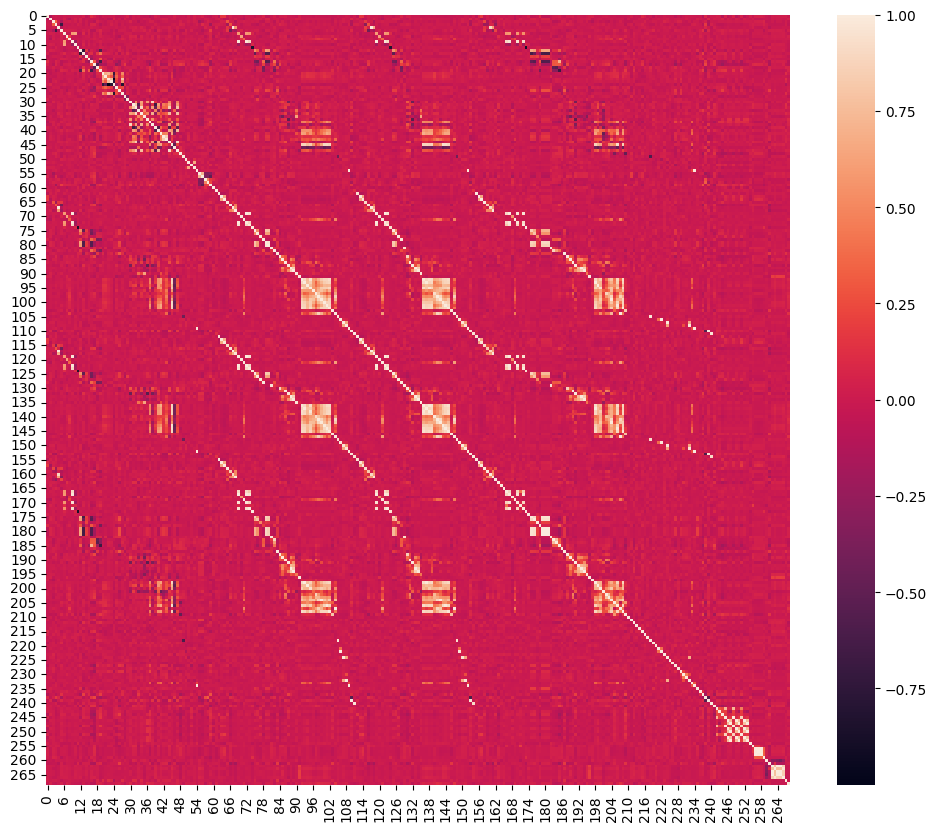

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Convert back to DataFrame

X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Correlation heatmap

plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr())

# Correlation matrix

corr_matrix = X_train.corr().abs()

# Upper triangle matrix

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated columns

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Columns to drop:", len(to_drop))

# Drop highly correlated features

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print("Shape after correlation filtering:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

3.ANOVA

In [46]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 100 important features using ANOVA F-test

selector = SelectKBest(score_func=f_classif, k=100)

# Fit and transform training data

X_train = selector.fit_transform(X_train, y_train)

# Transform test data

X_test = selector.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (1253, 100)
X_test shape : (314, 100)


4.Mutual Information

In [48]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Convert array back to DataFrame

X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Calculate MI scores

mi_scores = mutual_info_classif(X_train, y_train)

# Convert to Series

mi_scores = pd.Series(mi_scores, index=X_train.columns)

# Sort scores

mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores.head(20))

32    0.033034
37    0.026186
61    0.021048
26    0.020412
98    0.020308
0     0.018798
99    0.018729
34    0.018243
67    0.017443
31    0.017163
86    0.016097
30    0.015091
22    0.014749
45    0.013110
29    0.013077
35    0.012701
10    0.011527
48    0.011470
12    0.011099
60    0.010817
dtype: float64


In [49]:
# Select top 50 features

top_features = mi_scores.head(50).index

# Keep selected features

X_train = X_train[top_features]
X_test = X_test[top_features]

print(X_train.shape)
print(X_test.shape)

(1253, 50)
(314, 50)


==>Check

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize model

log_reg = LogisticRegression(max_iter=1000)

# Train model

log_reg.fit(X_train, y_train)

# Predictions

y_pred = log_reg.predict(X_test)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9363057324840764


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


5.Chi-Square

In [58]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Scale data to non-negative range (required for Chi-Square)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Chi-Square feature selection

selector = SelectKBest(score_func=chi2, k=25)

X_train_chi = selector.fit_transform(X_train_scaled, y_train)
X_test_chi = selector.transform(X_test_scaled)

print("X_train shape:", X_train_chi.shape)
print("X_test shape :", X_test_chi.shape)

X_train shape: (1253, 25)
X_test shape : (314, 25)


==>Check

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train model

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_chi, y_train)

# Predictions

y_pred = log_reg.predict(X_test_chi)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9331210191082803


In [ ]:
# ================================
# SECOM DATASET - OBSERVATIONS
# ================================

# Dataset Type:
# Industrial semiconductor manufacturing dataset

# Dataset Size:
# Rows    : 1567
# Columns : 591 features

# Target Variable:
# -1 -> Pass
#  1 -> Fail

# Key Problems in Dataset:
# 1. High dimensionality
# 2. Missing values
# 3. Duplicate features
# 4. Highly correlated features
# 5. Imbalanced dataset
# 6. Noisy sensor data

# ==========================================
# OBSERVATION 1 : Missing Value Analysis
# ==========================================

# Some columns had extremely high missing values
# Example:
# 91% missing values in certain columns

# Action Taken:
# Removed columns having >50% missing values

# Remaining missing values:
# Filled using median imputation

# Why Median?
# - Robust to outliers
# - Better for skewed industrial data

# ==========================================
# OBSERVATION 2 : Time Column
# ==========================================

# Time column was dropped because:
# - Not useful initially
# - Logistic Regression cannot directly use datetime
# - Could be feature engineered later if needed

# ==========================================
# OBSERVATION 3 : Duplicate Features
# ==========================================

# Duplicate columns existed in dataset

# Action Taken:
# Removed duplicate columns using:
# data.T.duplicated()

# Result:
# Feature count reduced significantly

# ==========================================
# OBSERVATION 4 : Initial Logistic Regression
# ==========================================

# After preprocessing:
# Remaining features ≈ 452

# Logistic Regression Accuracy:
# ~92%

# Important Observation:
# High accuracy may be misleading because dataset is imbalanced

# ==========================================
# OBSERVATION 5 : Variance Threshold
# ==========================================

# Applied VarianceThreshold

# Purpose:
# Remove low variance / low information features

# Benefit:
# Removes almost constant columns

# ==========================================
# OBSERVATION 6 : Correlation Filtering
# ==========================================

# Removed highly correlated features (>0.95)

# Purpose:
# - Remove redundant information
# - Reduce multicollinearity
# - Improve model efficiency

# ==========================================
# OBSERVATION 7 : ANOVA Feature Selection
# ==========================================

# Used:
# SelectKBest + f_classif

# Selected:
# Top 100 important features

# Purpose:
# Select features strongly related to target

# ==========================================
# OBSERVATION 8 : Mutual Information
# ==========================================

# Initial threshold approach:
# mi_scores > 0.05

# Result:
# 0 features selected

# Reason:
# MI scores were very small in noisy industrial dataset

# Solution:
# Selected top-k features instead

# Final:
# Selected top 50 features

# ==========================================
# OBSERVATION 9 : Feature Reduction
# ==========================================

# Features reduced from:
# 452 -> 50

# Reduction:
# ~89% feature reduction

# Surprisingly:
# Accuracy improved from 92% -> 93%

# Interpretation:
# Many original features were:
# - noisy
# - irrelevant
# - redundant

# ==========================================
# OBSERVATION 10 : Chi-Square Feature Selection
# ==========================================

# Chi-Square requires:
# Non-negative values

# Action Taken:
# Applied MinMaxScaler before chi-square

# Observation:
# Even with k=1 feature:
# Accuracy remained ~93%

# ==========================================
# IMPORTANT LEARNING
# ==========================================

# Accuracy is misleading in imbalanced datasets

# Reason:
# SECOM dataset has:
# ~93% Pass samples
# ~7% Fail samples

# A model predicting everything as PASS
# can still achieve ~93% accuracy

# ==========================================
# BETTER METRICS FOR IMBALANCED DATA
# ==========================================

# Instead of accuracy, use:
# - Precision
# - Recall
# - F1-score
# - ROC-AUC
# - BER (Balanced Error Rate)

# Most important:
# Recall for Fail class (1)

# ==========================================
# FINAL CONCLUSION
# ==========================================

# Feature selection improved:
# - Model simplicity
# - Generalization
# - Noise reduction
# - Computational efficiency

# Less but important features
# performed better than many noisy features.

# Final learning:
# More features != Better model

In [ ]:
# ==========================================
# DOUBT :
# How did Chi-Square work on numerical data?
# ==========================================

# Important:
# Chi-Square is generally designed for:
# - categorical data
# - frequency/count data
# - non-negative values

# But in sklearn:
# chi2() can also work on numerical features
# IF values are non-negative.

# ==========================================
# WHY IT FAILED INITIALLY
# ==========================================

# Our dataset had:
# - continuous numerical values
# - negative values possible

# Chi-Square cannot handle negative values.

# ==========================================
# SOLUTION USED
# ==========================================

# We applied:
# MinMaxScaler()

# This converted all feature values into:
# 0 to 1 range

# Example:

# Before Scaling:
# [-5.2, 10.7, 3.4]

# After MinMax Scaling:
# [0.0, 1.0, 0.53]

# Now all values became non-negative.

# Hence chi-square worked.

# ==========================================
# IMPORTANT CONCEPT
# ==========================================

# Chi-Square in sklearn does NOT check:
# "Is data categorical?"

# It only mathematically requires:
# feature values >= 0

# Therefore:
# continuous numerical data can also be used
# after converting to non-negative scale.

# ==========================================
# BUT THEORETICALLY
# ==========================================

# Chi-Square is still more suitable for:
# - categorical features
# - count/frequency data

# For continuous industrial sensor data,
# better feature selection methods are:

# - ANOVA F-Test
# - Mutual Information
# - Correlation Filtering
# - Variance Threshold

# ==========================================
# INTERVIEW POINT
# ==========================================

# Question:
# "Can Chi-Square be applied on numerical data?"

# Answer:
# Yes, in sklearn Chi-Square can be applied
# on numerical data if all feature values
# are non-negative. Therefore preprocessing
# like MinMaxScaler is commonly used before
# applying chi-square on continuous features.